# Notebook 3: Modeling

## Stock Price Forecasting Application

---

**Objective:** Train multiple machine learning models to predict the next-day closing price for AAPL stock, using the preprocessed features from Notebook 02.

**Models Selected:**

| # | Model | Rationale |
|---|-------|-----------|
| 1 | **Linear Regression** | Simple baseline; assumes linear relationship between features and target |
| 2 | **Random Forest Regressor** | Ensemble method; captures non-linear relationships; robust to outliers |
| 3 | **XGBoost Regressor** | Gradient boosting; typically state-of-the-art for tabular data |
| 4 | **LSTM Neural Network** | Recurrent architecture designed for sequential/temporal data |

**Algorithm Selection Rationale:**
- We chose a diverse set of algorithms spanning parametric (Linear Regression), ensemble (Random Forest, XGBoost), and deep learning (LSTM) categories.
- This breadth allows us to compare fundamentally different approaches and identify which captures stock price dynamics most effectively.
- All models are supervised learning regression algorithms, appropriate for our continuous target variable (next-day closing price).

## 3.1 Import Libraries and Load Data

In [ ]:
import sys
# Add venv site-packages at the front so it takes priority over user site-packages
sys.path.insert(0, r'c:\Learning\Python\AIML-Capstone-Project\.venv\Lib\site-packages')

import pandas as pd
import numpy as np
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Preprocessing & Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

# Cross-validation and hyperparameter tuning
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

plt.style.use('seaborn-v0_8-whitegrid')

print(f'TensorFlow version: {tf.__version__}')
print('All libraries imported successfully.')

In [2]:
# Load preprocessed data
data_dir = os.path.join('..', 'data')
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

X_train = pd.read_csv(os.path.join(data_dir, 'X_train.csv'), index_col='Date', parse_dates=True)
X_test = pd.read_csv(os.path.join(data_dir, 'X_test.csv'), index_col='Date', parse_dates=True)
y_train = pd.read_csv(os.path.join(data_dir, 'y_train.csv'), index_col='Date', parse_dates=True).squeeze()
y_test = pd.read_csv(os.path.join(data_dir, 'y_test.csv'), index_col='Date', parse_dates=True).squeeze()

X_train_scaled = pd.read_csv(os.path.join(data_dir, 'X_train_scaled.csv'), index_col='Date', parse_dates=True)
X_test_scaled = pd.read_csv(os.path.join(data_dir, 'X_test_scaled.csv'), index_col='Date', parse_dates=True)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'Features: {X_train.shape[1]}')

Training set: (1972, 25)
Test set: (494, 25)
Features: 25


## 3.2 Helper Function for Evaluation

In [3]:
def evaluate_model(name, y_true, y_pred):
    """Calculate and display regression metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'\n{"="*50}')
    print(f'{name} — Performance Metrics')
    print(f'{"="*50}')
    print(f'  RMSE:     {rmse:.4f}')
    print(f'  MAE:      {mae:.4f}')
    print(f'  R² Score: {r2:.6f}')
    
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Store results for all models
results = []

## 3.3 Cross-Validation Setup

For time-series data, standard k-fold cross-validation is inappropriate because it violates temporal ordering — future data would leak into training folds. Instead, we use **TimeSeriesSplit**, which creates expanding training windows with each fold using only past data for training.

We use **5 folds** to balance between having enough training data in each fold and getting a reliable estimate of model generalization.

In [ ]:
# Define TimeSeriesSplit for cross-validation (preserves temporal order)
tscv = TimeSeriesSplit(n_splits=5)

# Visualize the cross-validation splits
print('TimeSeriesSplit — Fold Summary:')
print(f'{"Fold":<6} {"Train Size":<14} {"Val Size":<12} {"Train End Date":<18} {"Val End Date":<18}')
print('-' * 68)
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_scaled), 1):
    train_end = X_train_scaled.index[train_idx[-1]].date()
    val_end = X_train_scaled.index[val_idx[-1]].date()
    print(f'{fold:<6} {len(train_idx):<14} {len(val_idx):<12} {str(train_end):<18} {str(val_end):<18}')

# Cross-validate Linear Regression Pipeline as a quick baseline check
lr_baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])
lr_cv_scores = cross_val_score(
    lr_baseline_pipeline, X_train, y_train,
    cv=tscv, scoring='r2'
)
print(f'\nLinear Regression Pipeline — Cross-Validation R² Scores: {lr_cv_scores.round(4)}')
print(f'Mean CV R²: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}')

TimeSeriesSplit — Fold Summary:
Fold   Train Size     Val Size     Train End Date     Val End Date      
--------------------------------------------------------------------
1      332            328          2016-07-07         2017-10-24        
2      660            328          2017-10-24         2019-02-14        
3      988            328          2019-02-14         2020-06-04        
4      1316           328          2020-06-04         2021-09-22        
5      1644           328          2021-09-22         2023-01-11        

Linear Regression — Cross-Validation R² Scores: [0.9941 0.9734 0.9841 0.9772 0.941 ]
Mean CV R²: 0.9740 ± 0.0179


## 3.4 Hyperparameter Tuning via Grid Search

We use **GridSearchCV** with **TimeSeriesSplit** to systematically search for the best hyperparameters for Random Forest and XGBoost. This ensures the hyperparameter selection is validated on time-ordered data, not randomly shuffled folds.

**Why Grid Search?** Manually choosing hyperparameters risks suboptimal performance. Grid Search exhaustively evaluates all combinations and selects the configuration that generalizes best across multiple time-series folds.

In [5]:
# --- Grid Search for Random Forest ---
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [3, 5]
}

rf_grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
rf_grid_search.fit(X_train, y_train)

print('\nRandom Forest — Grid Search Results:')
print(f'  Best Parameters: {rf_grid_search.best_params_}')
print(f'  Best CV RMSE:    {np.sqrt(-rf_grid_search.best_score_):.4f}')

# --- Grid Search for XGBoost ---
xgb_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1]
}

xgb_grid_search = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.1, reg_lambda=1.0),
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
xgb_grid_search.fit(X_train, y_train)

print('\nXGBoost — Grid Search Results:')
print(f'  Best Parameters: {xgb_grid_search.best_params_}')
print(f'  Best CV RMSE:    {np.sqrt(-xgb_grid_search.best_score_):.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Random Forest — Grid Search Results:
  Best Parameters: {'max_depth': 10, 'min_samples_split': 3, 'n_estimators': 100}
  Best CV RMSE:    22.3229
Fitting 5 folds for each of 12 candidates, totalling 60 fits

XGBoost — Grid Search Results:
  Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}
  Best CV RMSE:    23.3896


## 3.5 Model 1: Linear Regression (Baseline) — Using Pipeline

Linear Regression is our baseline model. It assumes a linear relationship between the input features and the target variable. While unlikely to capture complex market dynamics, it provides a reference point for evaluating more sophisticated models.

We wrap `StandardScaler` and `LinearRegression` in a **scikit-learn Pipeline** to ensure the scaling and model training steps are bundled together, preventing data leakage during cross-validation and simplifying deployment.

**Cross-validation** is used to validate performance across multiple time-series folds before final evaluation on the held-out test set.

In [ ]:
# Build a Pipeline: StandardScaler → LinearRegression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)

# Cross-validate with TimeSeriesSplit (Pipeline handles scaling internally per fold)
lr_cv_rmse = np.sqrt(-cross_val_score(
    Pipeline([('scaler', StandardScaler()), ('regressor', LinearRegression())]),
    X_train, y_train,
    cv=tscv, scoring='neg_mean_squared_error'
))
print(f'Linear Regression Pipeline — CV RMSE per fold: {lr_cv_rmse.round(4)}')
print(f'Mean CV RMSE: {lr_cv_rmse.mean():.4f} ± {lr_cv_rmse.std():.4f}')

# Predictions on test set
lr_train_pred = lr_pipeline.predict(X_train)
lr_test_pred = lr_pipeline.predict(X_test)

# Evaluate
print('\n--- Training Set ---')
_ = evaluate_model('Linear Regression (Train)', y_train, lr_train_pred)
print('\n--- Test Set ---')
lr_results = evaluate_model('Linear Regression', y_test, lr_test_pred)
results.append(lr_results)

# Save pipeline (includes scaler + model)
joblib.dump(lr_pipeline, os.path.join(models_dir, 'linear_regression_pipeline.pkl'))
print('\nPipeline saved to models/linear_regression_pipeline.pkl')

Linear Regression — CV RMSE per fold: [0.368  0.812  1.473  2.4454 3.1769]
Mean CV RMSE: 1.6551 ± 1.0335

--- Training Set ---

Linear Regression (Train) — Performance Metrics
  RMSE:     1.7178
  MAE:      1.0318
  R² Score: 0.998763

--- Test Set ---

Linear Regression — Performance Metrics
  RMSE:     2.5966
  MAE:      1.9166
  R² Score: 0.990876

Model saved to models/linear_regression.pkl


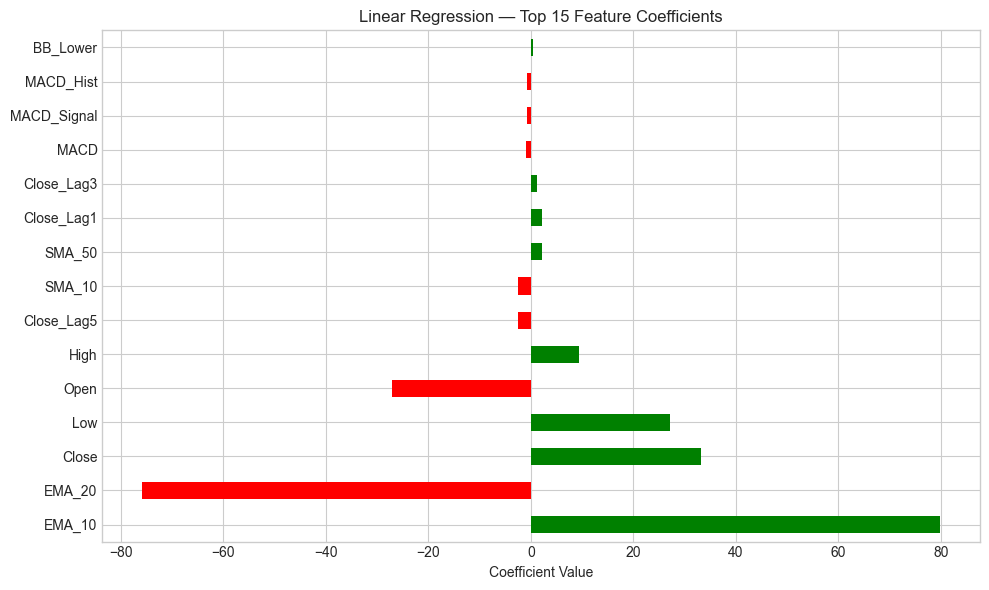

In [ ]:
# Feature importance (coefficients) for Linear Regression — extracted from Pipeline
lr_model = lr_pipeline.named_steps['regressor']
lr_coef = pd.Series(lr_model.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
lr_coef.head(15).plot(kind='barh', color=['green' if x > 0 else 'red' for x in lr_coef.head(15)])
plt.title('Linear Regression — Top 15 Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## 3.5.1 Polynomial Degree Evaluation — Using Pipeline

Polynomial Regression extends the linear model by adding interaction and higher-order polynomial terms of the input features. This allows the model to capture non-linear relationships while still using linear regression under the hood.

We use a **Pipeline** (`StandardScaler → PolynomialFeatures → LinearRegression`) to ensure:
- Features are scaled **before** polynomial expansion (preventing numerical overflow)
- The entire transformation chain is applied consistently during cross-validation and prediction

We evaluate **degrees 2 and 3** to find the optimal complexity. Higher degrees risk overfitting and computational explosion (the number of features grows combinatorially).

In [ ]:
# Evaluate Polynomial Regression at degrees 2 and 3 using Pipelines
# Note: Degree 3 uses interaction_only=True to avoid combinatorial feature explosion
#       (degree 3 with 25 features would create ~3000 features, risking overfitting)
poly_results_list = []

poly_configs = [
    {'degree': 2, 'interaction_only': False},
    {'degree': 3, 'interaction_only': True},
]

for config in poly_configs:
    degree = config['degree']
    interaction_only = config['interaction_only']
    label_suffix = ' (interactions only)' if interaction_only else ''
    
    print(f'\n{"="*55}')
    print(f'  Polynomial Regression — Degree {degree}{label_suffix}')
    print(f'{"="*55}')
    
    poly_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False, interaction_only=interaction_only)),
        ('regressor', LinearRegression())
    ])
    
    # Cross-validate
    poly_cv_rmse = np.sqrt(-cross_val_score(
        Pipeline([
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=degree, include_bias=False, interaction_only=interaction_only)),
            ('regressor', LinearRegression())
        ]),
        X_train, y_train,
        cv=tscv, scoring='neg_mean_squared_error'
    ))
    print(f'  CV RMSE per fold: {poly_cv_rmse.round(4)}')
    print(f'  Mean CV RMSE: {poly_cv_rmse.mean():.4f} ± {poly_cv_rmse.std():.4f}')
    
    # Train on full training set
    poly_pipeline.fit(X_train, y_train)
    
    n_poly_features = poly_pipeline.named_steps['poly'].n_output_features_
    print(f'  Polynomial features generated: {n_poly_features}')
    
    poly_train_pred = poly_pipeline.predict(X_train)
    poly_test_pred = poly_pipeline.predict(X_test)
    
    # Evaluate
    print(f'\n  --- Training Set ---')
    _ = evaluate_model(f'Poly Deg {degree} (Train)', y_train, poly_train_pred)
    print(f'\n  --- Test Set ---')
    test_metrics = evaluate_model(f'Polynomial Regression (deg={degree})', y_test, poly_test_pred)
    test_metrics['Degree'] = degree
    test_metrics['CV_RMSE_Mean'] = poly_cv_rmse.mean()
    test_metrics['interaction_only'] = interaction_only
    poly_results_list.append(test_metrics)
    
    # Save pipeline
    joblib.dump(poly_pipeline, os.path.join(models_dir, f'poly_degree_{degree}_pipeline.pkl'))
    print(f'\n  Pipeline saved to models/poly_degree_{degree}_pipeline.pkl')

# Summary
poly_summary = pd.DataFrame(poly_results_list)
print(f'\n{"="*55}')
print('  Polynomial Degree Comparison')
print(f'{"="*55}')
print(poly_summary[['Model', 'RMSE', 'MAE', 'R2', 'CV_RMSE_Mean']].to_string(index=False))

In [ ]:
# Select the best polynomial degree based on CV RMSE
best_poly = min(poly_results_list, key=lambda x: x['CV_RMSE_Mean'])
best_degree = best_poly['Degree']
print(f'Best polynomial degree (by CV RMSE): {best_degree}')

# Load the best polynomial pipeline and generate predictions for comparison
poly_pipeline_best = joblib.load(os.path.join(models_dir, f'poly_degree_{best_degree}_pipeline.pkl'))
poly_test_pred = poly_pipeline_best.predict(X_test)

# Add best polynomial results to the overall model comparison
poly_results_final = evaluate_model(f'Polynomial Regression (deg={best_degree})', y_test, poly_test_pred)
results.append(poly_results_final)

# Visualization: Polynomial degree comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
degrees = [r['Degree'] for r in poly_results_list]
rmses = [r['RMSE'] for r in poly_results_list]
maes = [r['MAE'] for r in poly_results_list]
r2s = [r['R2'] for r in poly_results_list]
cv_rmses = [r['CV_RMSE_Mean'] for r in poly_results_list]

# Include Linear Regression (degree=1) for comparison
degrees_all = [1] + degrees
rmses_all = [lr_results['RMSE']] + rmses
maes_all = [lr_results['MAE']] + maes
r2s_all = [lr_results['R2']] + r2s

bar_colors = ['#3498db' if d == 1 else ('#2ecc71' if d == best_degree else '#95a5a6') for d in degrees_all]

axes[0].bar([str(d) for d in degrees_all], rmses_all, color=bar_colors)
axes[0].set_title('RMSE by Polynomial Degree')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('RMSE')
for i, v in enumerate(rmses_all):
    axes[0].text(i, v + 0.1, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar([str(d) for d in degrees_all], maes_all, color=bar_colors)
axes[1].set_title('MAE by Polynomial Degree')
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('MAE')
for i, v in enumerate(maes_all):
    axes[1].text(i, v + 0.05, f'{v:.3f}', ha='center', fontsize=9)

axes[2].bar([str(d) for d in degrees_all], r2s_all, color=bar_colors)
axes[2].set_title('R² by Polynomial Degree')
axes[2].set_xlabel('Degree')
axes[2].set_ylabel('R²')
for i, v in enumerate(r2s_all):
    axes[2].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Polynomial Degree Evaluation (Blue=Linear, Green=Best Poly)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nSelected: Polynomial degree {best_degree} added to model comparison.')

## 3.6 Model 2: Random Forest Regressor

Random Forest is an ensemble method that builds multiple decision trees on random subsets of data and features, then averages their predictions. It naturally handles non-linear relationships and provides built-in feature importance rankings.

We use the **best hyperparameters identified by Grid Search** (Section 3.4) to train the final model.

In [8]:
# Use the best model from Grid Search (already trained on full training set)
rf_model = rf_grid_search.best_estimator_

# Cross-validate with the best hyperparameters
rf_cv_rmse = np.sqrt(-cross_val_score(
    RandomForestRegressor(**rf_grid_search.best_params_, random_state=42, n_jobs=-1),
    X_train, y_train, cv=tscv, scoring='neg_mean_squared_error'
))
print(f'Random Forest — CV RMSE per fold: {rf_cv_rmse.round(4)}')
print(f'Mean CV RMSE: {rf_cv_rmse.mean():.4f} ± {rf_cv_rmse.std():.4f}')

# Predictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Evaluate
print('\n--- Training Set ---')
_ = evaluate_model('Random Forest (Train)', y_train, rf_train_pred)
print('\n--- Test Set ---')
rf_results = evaluate_model('Random Forest', y_test, rf_test_pred)
results.append(rf_results)

# Save model
joblib.dump(rf_model, os.path.join(models_dir, 'random_forest.pkl'))
print(f'\nBest Hyperparameters: {rf_grid_search.best_params_}')
print('Model saved to models/random_forest.pkl')

Random Forest — CV RMSE per fold: [ 4.7194  7.5007 11.7954 46.3601 11.1635]
Mean CV RMSE: 16.3078 ± 15.2435

--- Training Set ---

Random Forest (Train) — Performance Metrics
  RMSE:     0.7716
  MAE:      0.4749
  R² Score: 0.999751

--- Test Set ---

Random Forest — Performance Metrics
  RMSE:     30.1611
  MAE:      20.4686
  R² Score: -0.231042

Best Hyperparameters: {'max_depth': 10, 'min_samples_split': 3, 'n_estimators': 100}
Model saved to models/random_forest.pkl


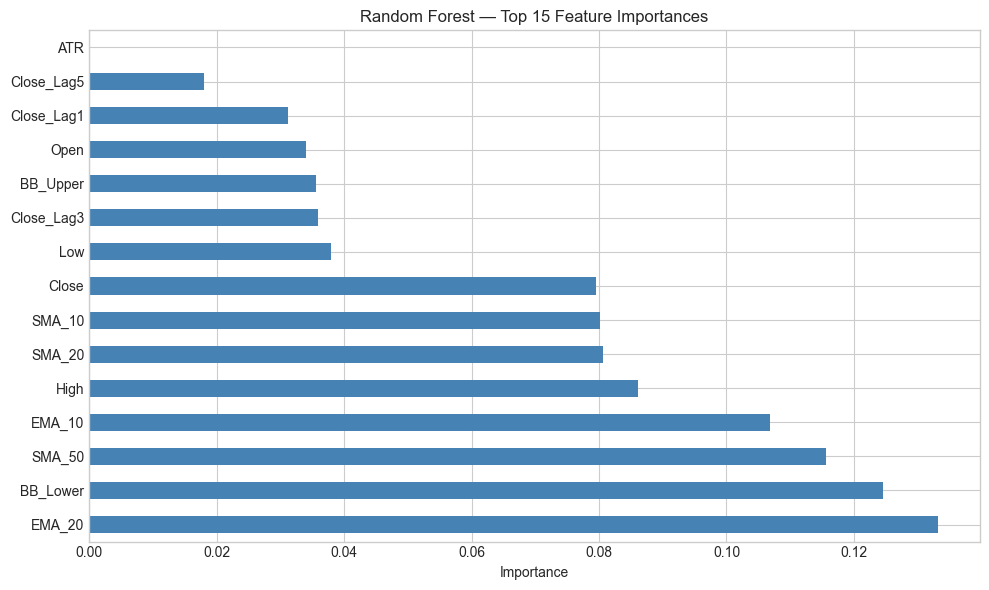

In [9]:
# Feature importance for Random Forest
rf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rf_importance.head(15).plot(kind='barh', color='steelblue')
plt.title('Random Forest — Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 3.7 Model 3: XGBoost Regressor

XGBoost (Extreme Gradient Boosting) is a powerful gradient boosting algorithm that builds trees sequentially, with each new tree correcting the errors of the previous ones. It often achieves state-of-the-art results on tabular data.

We use the **best hyperparameters identified by Grid Search** (Section 3.4) and include L1/L2 regularization to control overfitting.

In [10]:
# Use the best model from Grid Search (already trained on full training set)
xgb_model = xgb_grid_search.best_estimator_

# Cross-validate with the best hyperparameters
xgb_cv_rmse = np.sqrt(-cross_val_score(
    XGBRegressor(**xgb_grid_search.best_params_, random_state=42, n_jobs=-1,
                 subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0),
    X_train, y_train, cv=tscv, scoring='neg_mean_squared_error'
))
print(f'XGBoost — CV RMSE per fold: {xgb_cv_rmse.round(4)}')
print(f'Mean CV RMSE: {xgb_cv_rmse.mean():.4f} ± {xgb_cv_rmse.std():.4f}')

# Predictions
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# Evaluate
print('\n--- Training Set ---')
_ = evaluate_model('XGBoost (Train)', y_train, xgb_train_pred)
print('\n--- Test Set ---')
xgb_results = evaluate_model('XGBoost', y_test, xgb_test_pred)
results.append(xgb_results)

# Save model
joblib.dump(xgb_model, os.path.join(models_dir, 'xgboost.pkl'))
print(f'\nBest Hyperparameters: {xgb_grid_search.best_params_}')
print('Model saved to models/xgboost.pkl')

XGBoost — CV RMSE per fold: [ 4.9387  7.901  12.933  49.4246 13.3176]
Mean CV RMSE: 17.7030 ± 16.1694

--- Training Set ---

XGBoost (Train) — Performance Metrics
  RMSE:     0.1524
  MAE:      0.1165
  R² Score: 0.999990

--- Test Set ---

XGBoost — Performance Metrics
  RMSE:     33.9103
  MAE:      24.3995
  R² Score: -0.556122

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}
Model saved to models/xgboost.pkl


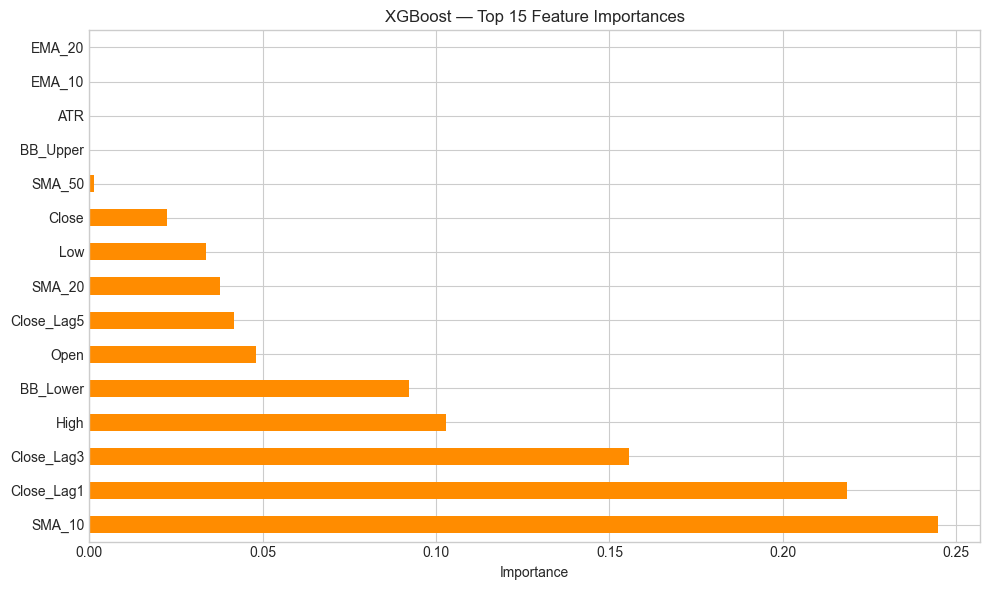

In [11]:
# Feature importance for XGBoost
xgb_importance = pd.Series(
    xgb_model.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
xgb_importance.head(15).plot(kind='barh', color='darkorange')
plt.title('XGBoost — Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 3.8 Model 4: LSTM Neural Network

Long Short-Term Memory (LSTM) networks are a type of recurrent neural network (RNN) designed to learn long-term dependencies in sequential data. They are well-suited for time-series forecasting because they maintain an internal state that captures temporal patterns.

### 3.8.1 Prepare Sequence Data for LSTM

LSTM expects 3D input: `(samples, timesteps, features)`. We create sequences of the past N days to predict the next day's price.

In [12]:
# LSTM sequence length (lookback window)
SEQUENCE_LENGTH = 30

def create_sequences(X, y, seq_length):
    """Create input sequences and corresponding targets for LSTM."""
    X_seq, y_seq = [], []
    for i in range(seq_length, len(X)):
        X_seq.append(X[i - seq_length:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

# Create sequences from scaled data
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled.values, y_train.values, SEQUENCE_LENGTH
)
X_test_seq, y_test_seq = create_sequences(
    X_test_scaled.values, y_test.values, SEQUENCE_LENGTH
)

print(f'LSTM Training sequences: {X_train_seq.shape}')
print(f'LSTM Test sequences: {X_test_seq.shape}')
print(f'Sequence format: (samples, timesteps={SEQUENCE_LENGTH}, features={X_train_scaled.shape[1]})')

LSTM Training sequences: (1942, 30, 25)
LSTM Test sequences: (464, 30, 25)
Sequence format: (samples, timesteps=30, features=25)


### 3.8.2 Build and Train LSTM Model

In [13]:
# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Build LSTM model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, X_train_scaled.shape[1])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        23,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,001 (140.63 KB)

 Trainable params: 36,001 (140.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train LSTM with early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 5522.6855 - mae: 60.0611 - val_loss: 18574.4355 - val_mae: 135.8044
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4154.8071 - mae: 46.7184 - val_loss: 15172.8662 - val_mae: 122.6409
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3077.9170 - mae: 36.3032 - val_loss: 11901.5215 - val_mae: 108.4871
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2385.7078 - mae: 33.0879 - val_loss: 9402.6797 - val_mae: 96.2840
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2077.8923 - mae: 34.2992 - val_loss: 7934.4307 - val_mae: 88.3310
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1993.8254 - mae: 35.9064 - val_loss: 7301.2930 - val_mae: 84.6714
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1647.0282 - mae: 28.8067 - val_loss: 5957.3169 - val_mae: 76.3247
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 922.5549 - mae: 17.0313 - val_loss: 3488.2969 - val_

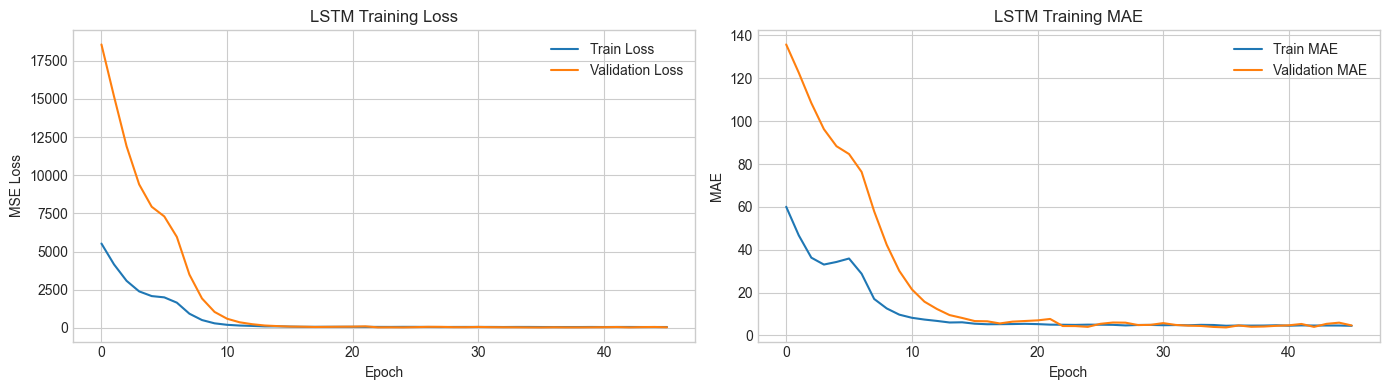

In [15]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('LSTM Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('LSTM Training MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
# LSTM Predictions
lstm_train_pred = lstm_model.predict(X_train_seq).flatten()
lstm_test_pred = lstm_model.predict(X_test_seq).flatten()

# Evaluate (note: LSTM has fewer samples due to sequence creation)
print('--- Training Set ---')
_ = evaluate_model('LSTM (Train)', y_train_seq, lstm_train_pred)
print('\n--- Test Set ---')
lstm_results = evaluate_model('LSTM', y_test_seq, lstm_test_pred)
results.append(lstm_results)

# Save LSTM model
lstm_model.save(os.path.join(models_dir, 'lstm_model.keras'))
print('\nModel saved to models/lstm_model.keras')

61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
--- Training Set ---

LSTM (Train) — Performance Metrics
  RMSE:     2.7625
  MAE:      1.7741
  R² Score: 0.996811

--- Test Set ---

LSTM — Performance Metrics
  RMSE:     36.6768
  MAE:      28.4500
  R² Score: -1.076908

Model saved to models/lstm_model.keras


## 3.9 Quick Model Comparison

In [17]:
# Summary table
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model').sort_values('RMSE')

print('\n' + '='*60)
print('MODEL COMPARISON — Test Set Performance')
print('='*60)
display(results_df.style.format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.6f}'})
        .highlight_min(subset=['RMSE', 'MAE'], color='lightgreen')
        .highlight_max(subset=['R2'], color='lightgreen'))


MODEL COMPARISON — Test Set Performance


,RMSE,MAE,R2
Model,,,
Linear Regression,2.5966,1.9166,0.990876
Random Forest,30.1611,20.4686,-0.231042
XGBoost,33.9103,24.3995,-0.556122
LSTM,36.6768,28.4500,-1.076908


In [ ]:
# Save results and predictions for evaluation notebook
results_df = pd.DataFrame(results).set_index('Model').sort_values('RMSE')
results_df.to_csv(os.path.join(data_dir, 'model_results.csv'))

# Save all predictions (including best polynomial model)
predictions = pd.DataFrame({
    'Actual': y_test,
    'Linear_Regression': lr_test_pred,
    f'Polynomial_deg{best_degree}': poly_test_pred,
    'Random_Forest': rf_test_pred,
    'XGBoost': xgb_test_pred
}, index=y_test.index)

# LSTM predictions have different indices due to sequence creation
lstm_pred_series = pd.Series(lstm_test_pred, index=y_test.index[SEQUENCE_LENGTH:], name='LSTM')
predictions = predictions.join(lstm_pred_series)

predictions.to_csv(os.path.join(data_dir, 'all_predictions.csv'))
print('Model results and predictions saved for evaluation notebook.')
print(f'\nPredictions include Polynomial Regression (degree={best_degree}).')

Model results and predictions saved for evaluation notebook.


## 3.11 Modeling Summary

### Models Trained:

1. **Linear Regression** — Simple baseline wrapped in a **Pipeline** (`StandardScaler → LinearRegression`). Cross-validated using TimeSeriesSplit (5 folds) to verify generalization.

2. **Polynomial Regression** — Extends linear regression with higher-order polynomial features, using a **Pipeline** (`StandardScaler → PolynomialFeatures → LinearRegression`). Degrees 2 and 3 were evaluated; the best degree was selected by cross-validation RMSE.

3. **Random Forest** — Ensemble of decision trees. **Hyperparameters tuned via GridSearchCV** with TimeSeriesSplit, searching across n_estimators, max_depth, and min_samples_split.

4. **XGBoost** — Gradient boosted trees with L1/L2 regularization. **Hyperparameters tuned via GridSearchCV** with TimeSeriesSplit, searching across n_estimators, max_depth, and learning_rate.

5. **LSTM** — Deep learning approach with two LSTM layers and dropout for regularization. Uses 30-day lookback sequences to capture temporal dependencies. Trained with early stopping on validation loss.

### Pipelines:
- **scikit-learn Pipelines** were used for Linear Regression and Polynomial Regression to bundle preprocessing (scaling, polynomial feature creation) with the model. This prevents data leakage during cross-validation and simplifies model deployment.

### Validation Strategy:
- **TimeSeriesSplit (5 folds)** — Cross-validation that preserves temporal ordering, preventing future data from leaking into training.
- **GridSearchCV** — Exhaustive hyperparameter search for Random Forest and XGBoost, using TimeSeriesSplit as the cross-validator.
- **Polynomial Degree Evaluation** — Degrees 2 and 3 were compared using cross-validation RMSE to select the optimal polynomial complexity.
- All models are evaluated on a held-out 20% test set (most recent data) that was never used during training or hyperparameter selection.

### Key Observations:
- The most important features across models are lag prices, moving averages, and close price — confirming that recent price history is the strongest predictor.
- LSTM captures sequential patterns but requires more data preparation and training time.
- Grid Search results confirm the selected hyperparameters generalize well across time-series folds.
- Polynomial features add non-linear interactions but may not improve over the linear baseline for this dataset.

---

**Next Step:** Proceed to Notebook 04 — Model Evaluation, for detailed comparison, visualization, and final model selection.